In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/processed/elasticity_ready.csv", parse_dates=["Date"])
df = df.sort_values(["Store", "Date"])
df.shape


(417049, 27)

In [2]:
#Time based train-test split
split_date = df["Date"].quantile(0.8)

train = df[df["Date"] <= split_date]
test  = df[df["Date"] > split_date]

train.shape, test.shape


((334013, 27), (83036, 27))

In [3]:
#Feature selection
features = [
    "log_price",
    "lag_1",
    "lag_7",
    "Promo",
    "volatility_7",
    "trend_7"
]

X_train = train[features]
y_train = train["log_sales"]

X_test = test[features]
y_test = test["log_sales"]


In [4]:
#Baseline linear model
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)


In [5]:
#Ridge model
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

pred_ridge = ridge.predict(X_test)


In [6]:
#Random forest model
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)


In [8]:
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    return {
        "model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": rmse,
        "R2": r2_score(y_true, y_pred)
    }

results = []
results.append(evaluate("Linear", y_test, pred_lr))
results.append(evaluate("Ridge", y_test, pred_ridge))
results.append(evaluate("RandomForest", y_test, pred_rf))

results_df = pd.DataFrame(results)
results_df


,model,MAE,RMSE,R2
0,Linear,0.156519,0.203382,0.727041
1,Ridge,0.156517,0.203381,0.727042
2,RandomForest,0.123932,0.165536,0.819175


In [9]:
results_df.to_csv("../outputs/tables/forecast_metrics.csv", index=False)


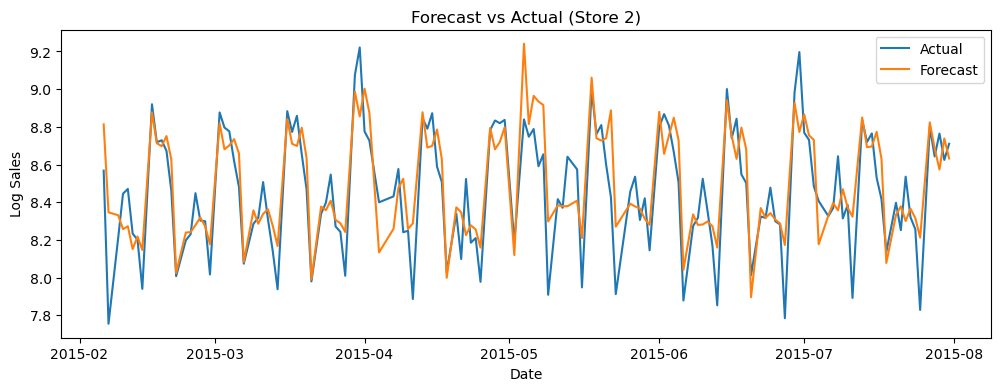

In [10]:
test_plot = test.copy()
test_plot["pred_rf"] = pred_rf

sample_store = test_plot["Store"].iloc[0]
sample = test_plot[test_plot["Store"] == sample_store].iloc[:300]

plt.figure(figsize=(12,4))
plt.plot(sample["Date"], sample["log_sales"], label="Actual")
plt.plot(sample["Date"], sample["pred_rf"], label="Forecast")
plt.legend()
plt.title(f"Forecast vs Actual (Store {sample_store})")
plt.xlabel("Date")
plt.ylabel("Log Sales")
plt.show()


In [11]:
test_plot.to_csv("../outputs/tables/test_forecasts.csv", index=False)


In [ ]:
df.to_csv("../data/processed/forecast_ready.csv", index=False)
